In [1]:
import numpy as np
from pathlib import Path
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA RTX A6000


Cutivar Dictionary:

In [2]:
DATASET_DIR = Path("Dataset")

CULTIVARS = {
    "AAC_Chrome":     {"label": "AAC Chrome",    "cys": 0.317211},
    "AAC_Lacombe":    {"label": "AAC Lacombe",   "cys": 0.338561},
    "AAC_Liscard":    {"label": "AAC Liscard",   "cys": 0.325405},
    "CDC_Amarillo":   {"label": "CDC Amarillo",  "cys": 0.358930},
    "CDC_Athabasca":  {"label": "CDC Athabasca", "cys": 0.341203},
    "CDC_Canary":     {"label": "CDC Canary",    "cys": 0.314476},
    "CDC_Dakota":     {"label": "CDC Dakota",    "cys": 0.332835},
    "CDC_Golden":     {"label": "CDC Golden",    "cys": 0.359066},
    "CDC_Greenwater": {"label": "CDC Greenwater","cys": 0.346381},
    "CDC_Inca":       {"label": "CDC Inca",      "cys": 0.365342},
    "CDC_Jasper":     {"label": "CDC Jasper",    "cys": 0.337341},
    "CDC_Lewochko":   {"label": "CDC Lewochko",  "cys": 0.341267},
    "CDC_Meadow":     {"label": "CDC Meadow",    "cys": 0.312012},
    "CDC_Patrick":    {"label": "CDC Patrick",   "cys": 0.338404},
    "CDC_Saffron":    {"label": "CDC Saffron",   "cys": 0.346789},
    "CDC_Spectrum":   {"label": "CDC Spectrum",  "cys": 0.373175},
    "CDC_Spruce":     {"label": "CDC Spruce",    "cys": 0.345676},
    "CDC_Striker":    {"label": "CDC Striker",   "cys": 0.344968},
    "CDC_Tetris":     {"label": "CDC Tetris",    "cys": 0.342040},
    "Redbat88":       {"label": "Redbat 88",     "cys": 0.316257},
}

read_spectrum function:

In [3]:
def read_spectrum(filepath):
    raman_shifts = []
    intensities = []

    with open(filepath, 'r', encoding='latin-1') as f:
        lines = f.readlines()

    data_started = False
    for line in lines:
        line = line.strip()
        if line.startswith("Pixel;"):
            data_started = True
            continue
        if not data_started:
            continue
        parts = line.split(';')
        if len(parts) < 8:
            continue
        wl_str = parts[1].strip()
        if not wl_str or wl_str == '   ':
            continue
        try:
            raman_shift = float(parts[3])
            dark_sub    = float(parts[7])
            raman_shifts.append(raman_shift)
            intensities.append(dark_sub)
        except ValueError:
            continue

    return raman_shifts, intensities

Preprocessing functions and combos:

In [4]:
all_data = {}

for folder_name, meta in CULTIVARS.items():
    folder_path = DATASET_DIR / folder_name
    if not folder_path.exists():
        print(f"Not found: {folder_name}")
        continue
    files = list(folder_path.rglob("*.txt"))
    spectra = []
    for f in files:
        rs, intens = read_spectrum(f)
        if len(rs) > 100:
            spectra.append((rs, intens))
    all_data[folder_name] = spectra
    print(f"{meta['label']}: {len(spectra)} spectra loaded")

    

AAC Chrome: 324 spectra loaded
AAC Lacombe: 324 spectra loaded
AAC Liscard: 324 spectra loaded
CDC Amarillo: 324 spectra loaded
CDC Athabasca: 324 spectra loaded
CDC Canary: 324 spectra loaded
CDC Dakota: 324 spectra loaded
CDC Golden: 324 spectra loaded
CDC Greenwater: 324 spectra loaded
CDC Inca: 324 spectra loaded
CDC Jasper: 324 spectra loaded
CDC Lewochko: 324 spectra loaded
CDC Meadow: 324 spectra loaded
CDC Patrick: 324 spectra loaded
CDC Saffron: 324 spectra loaded
CDC Spectrum: 324 spectra loaded
CDC Spruce: 324 spectra loaded
CDC Striker: 324 spectra loaded
CDC Tetris: 324 spectra loaded
Redbat 88: 324 spectra loaded


In [5]:
def savitzky_golay_smooth(X, window=11, poly=3):
    return savgol_filter(X, window_length=window, polyorder=poly, axis=1)

def snv(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True)
    return (X - mean) / std

def msc(X):
    mean_spectrum = X.mean(axis=0)
    X_msc = np.zeros_like(X)
    for i in range(X.shape[0]):
        coef = np.polyfit(mean_spectrum, X[i], 1)
        X_msc[i] = (X[i] - coef[1]) / coef[0]
    return X_msc

def first_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=1, axis=1)

def second_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=2, axis=1)

preprocessing_combos = {
    "SG + SNV":           lambda X: snv(savitzky_golay_smooth(X)),
    "SG + MSC":           lambda X: msc(savitzky_golay_smooth(X)),
    "SG + 1st Deriv":     lambda X: first_derivative(savitzky_golay_smooth(X)),
    "SG + 2nd Deriv":     lambda X: second_derivative(savitzky_golay_smooth(X)),
    "SG + SNV + 1st Der": lambda X: first_derivative(snv(savitzky_golay_smooth(X))),
    "SG + SNV + 2nd Der": lambda X: second_derivative(snv(savitzky_golay_smooth(X))),
    "SG + MSC + 1st Der": lambda X: first_derivative(msc(savitzky_golay_smooth(X))),
    "SG + MSC + 2nd Der": lambda X: second_derivative(msc(savitzky_golay_smooth(X))),
}

print(f"Preprocessing combinations: {len(preprocessing_combos)}")

Preprocessing combinations: 8


Build x and y:

In [6]:
X = []
y = []

for folder_name, meta in CULTIVARS.items():
    spectra = all_data.get(folder_name, [])
    for rs, intens in spectra:
        X.append(intens)
        y.append(meta['cys'])

X = np.array(X)
y = np.array(y)

cultivar_names = list(CULTIVARS.keys())

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (6480, 1530)
y shape: (6480,)


CNN-LSTM Architecture:

In [7]:
class CNNLSTMModel(nn.Module):
    def __init__(self, input_size=1530, hidden_size=128,
                 num_layers=2, dropout=0.3):
        super(CNNLSTMModel, self).__init__()

        # ── CNN feature extractor ──
        self.cnn = nn.Sequential(
            # Block 1
            nn.Conv1d(1, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Block 2
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Block 3
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )
        # After 3 pooling layers: 1530 / 8 = 191 time steps
        # Each time step has 64 features

        # ── LSTM sequence learner ──
        self.lstm = nn.LSTM(
            input_size=64,          # CNN output features per time step
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )

        # ── Fully connected output ──
        self.fc_layers = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),  # *2 for bidirectional
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x shape: (batch, 1530)
        x = x.unsqueeze(1)          # → (batch, 1, 1530) for Conv1d
        x = self.cnn(x)             # → (batch, 64, 191)
        x = x.permute(0, 2, 1)     # → (batch, 191, 64) for LSTM
        lstm_out, _ = self.lstm(x)  # → (batch, 191, hidden*2)
        out = lstm_out[:, -1, :]    # → take last time step (batch, hidden*2)
        out = self.fc_layers(out)   # → (batch, 1)
        return out.squeeze(1)       # → (batch,)

# Test architecture
model_test = CNNLSTMModel(input_size=1530, hidden_size=128, num_layers=2)
print(model_test)
print(f"\nTotal parameters: {sum(p.numel() for p in model_test.parameters()):,}")

# Test with dummy input
dummy = torch.randn(4, 1530)
out   = model_test(dummy)
print(f"Input shape:  {dummy.shape}")
print(f"Output shape: {out.shape}  ← should be (4,)")

CNNLSTMModel(
  (cnn): Sequential(
    (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc_layers): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): 

Training Function:

In [8]:
def train_model(model, X_train, y_train, X_val, y_val,
                epochs=100, batch_size=32, lr=1e-4):

    X_tr = torch.FloatTensor(X_train).to(device)
    y_tr = torch.FloatTensor(y_train).to(device)
    X_v  = torch.FloatTensor(X_val).to(device)
    y_v  = torch.FloatTensor(y_val).to(device)

    dataset   = TensorDataset(X_tr, y_tr)
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.SmoothL1Loss(beta=0.02)
    optimizer = optim.AdamW(model.parameters(),
                            lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(
                    optimizer, max_lr=lr,
                    steps_per_epoch=len(loader),
                    epochs=epochs)

    model.to(device)

    best_val_loss = np.inf
    best_weights  = None
    train_losses  = []
    val_losses    = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss   = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(loader)
        train_losses.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            y_val_pred = model(X_v)
            val_loss   = criterion(y_val_pred, y_v).item()
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} — "
                  f"Train Loss: {avg_train_loss:.5f}  "
                  f"Val Loss: {val_loss:.5f}")

    model.load_state_dict(best_weights)
    print(f"\nBest validation loss: {best_val_loss:.5f}")
    return model, train_losses, val_losses

CNN-LSTM Preprocessing comparison:

In [9]:
results_cnnlstm = []

for combo_name, preprocess_fn in preprocessing_combos.items():
    print(f"\n{'='*50}")
    print(f"Testing: {combo_name}")
    print(f"{'='*50}")

    try:
        X_combo = preprocess_fn(X)
    except Exception as e:
        print(f"  Failed: {e}")
        continue

    # 80/20 split
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_combo, y, test_size=0.2, random_state=42
    )

    # Train CNN-LSTM 80/20
    torch.manual_seed(42)
    model_combo = CNNLSTMModel(input_size=1530, hidden_size=128, num_layers=2)
    model_combo, _, _ = train_model(
        model=model_combo,
        X_train=X_tr, y_train=y_tr,
        X_val=X_te,   y_val=y_te,
        epochs=100, batch_size=32, lr=1e-4
    )

    model_combo.eval()
    with torch.no_grad():
        y_pred_te = model_combo(
            torch.FloatTensor(X_te).to(device)
        ).cpu().numpy()

    rmse_8020 = np.sqrt(mean_squared_error(y_te, y_pred_te))
    r2_8020   = r2_score(y_te, y_pred_te)
    rpd_8020  = y_te.std() / rmse_8020

    print(f"  80/20 → RMSE: {rmse_8020:.4f}  R²: {r2_8020:.4f}  RPD: {rpd_8020:.4f}")

    # LOCOCV
    all_true, all_pred = [], []

    for fold_idx, held_out in enumerate(cultivar_names):
        X_tr_l, y_tr_l = [], []
        X_te_l, y_te_l = [], []

        for folder_name, meta in CULTIVARS.items():
            spectra = all_data.get(folder_name, [])
            for rs, intens in spectra:
                arr     = np.array([intens])
                arr_pre = preprocess_fn(arr)[0]
                if folder_name == held_out:
                    X_te_l.append(arr_pre)
                    y_te_l.append(meta['cys'])
                else:
                    X_tr_l.append(arr_pre)
                    y_tr_l.append(meta['cys'])

        torch.manual_seed(42)
        model_loco = CNNLSTMModel(input_size=1530, hidden_size=128, num_layers=2)
        model_loco, _, _ = train_model(
            model=model_loco,
            X_train=np.array(X_tr_l),
            y_train=np.array(y_tr_l),
            X_val=np.array(X_te_l),
            y_val=np.array(y_te_l),
            epochs=100, batch_size=32, lr=1e-4
        )

        model_loco.eval()
        with torch.no_grad():
            y_pred_l = model_loco(
                torch.FloatTensor(np.array(X_te_l)).to(device)
            ).cpu().numpy()

        all_true.extend(y_te_l)
        all_pred.extend(y_pred_l)

        fold_rmse = np.sqrt(mean_squared_error(y_te_l, y_pred_l))
        print(f"    Fold {fold_idx+1}/20 {CULTIVARS[held_out]['label']:20s} RMSE: {fold_rmse:.4f}")

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    rmse_loco = np.sqrt(mean_squared_error(all_true, all_pred))
    r2_loco   = r2_score(all_true, all_pred)
    rpd_loco  = all_true.std() / rmse_loco

    print(f"\n  LOCO → RMSE: {rmse_loco:.4f}  R²: {r2_loco:.4f}  RPD: {rpd_loco:.4f}")

    results_cnnlstm.append({
        "Preprocessing": combo_name,
        "RMSE_8020":     rmse_8020,
        "R2_8020":       r2_8020,
        "RPD_8020":      rpd_8020,
        "RMSE_LOCO":     rmse_loco,
        "R2_LOCO":       r2_loco,
        "RPD_LOCO":      rpd_loco,
    })



Testing: SG + SNV
Epoch  10/100 — Train Loss: 0.04263  Val Loss: 0.00667
Epoch  20/100 — Train Loss: 0.03776  Val Loss: 0.00659
Epoch  30/100 — Train Loss: 0.02954  Val Loss: 0.00593
Epoch  40/100 — Train Loss: 0.02320  Val Loss: 0.00598
Epoch  50/100 — Train Loss: 0.01695  Val Loss: 0.00577
Epoch  60/100 — Train Loss: 0.01297  Val Loss: 0.00549
Epoch  70/100 — Train Loss: 0.01024  Val Loss: 0.00488
Epoch  80/100 — Train Loss: 0.00887  Val Loss: 0.00477
Epoch  90/100 — Train Loss: 0.00828  Val Loss: 0.00477
Epoch 100/100 — Train Loss: 0.00811  Val Loss: 0.00473

Best validation loss: 0.00470
  80/20 → RMSE: 0.0142  R²: 0.2496  RPD: 1.1544
Epoch  10/100 — Train Loss: 0.04123  Val Loss: 0.02460
Epoch  20/100 — Train Loss: 0.03576  Val Loss: 0.02182
Epoch  30/100 — Train Loss: 0.02805  Val Loss: 0.02292
Epoch  40/100 — Train Loss: 0.01915  Val Loss: 0.01199
Epoch  50/100 — Train Loss: 0.01273  Val Loss: 0.02240
Epoch  60/100 — Train Loss: 0.00829  Val Loss: 0.01575
Epoch  70/100 — Train 

Results table and comparison plot:

         CNN-LSTM PREPROCESSING COMPARISON RESULTS
Preprocessing           RMSE_8020  R2_8020  RPD_8020  RMSE_LOCO   R2_LOCO  RPD_LOCO
------------------------------------------------------------------------------------------
SG + SNV                   0.0142   0.2496    1.1544     0.0086    0.7282    1.9183
SG + MSC                   0.0141   0.2547    1.1583     0.0091    0.6937    1.8068
SG + 1st Deriv             0.0160   0.0466    1.0242     0.0107    0.5729    1.5302
SG + 2nd Deriv             0.0162   0.0166    1.0084     0.0106    0.5818    1.5463
SG + SNV + 1st Der         0.0153   0.1242    1.0685     0.0108    0.5718    1.5281
SG + SNV + 2nd Der         0.0154   0.1147    1.0628     0.0105    0.5934    1.5683
SG + MSC + 1st Der         0.0154   0.1205    1.0663     0.0108    0.5700    1.5250
SG + MSC + 2nd Der         0.0154   0.1178    1.0647     0.0106    0.5848    1.5519

Best 80/20 preprocessing: SG + MSC
Best LOCO  preprocessing: SG + SNV


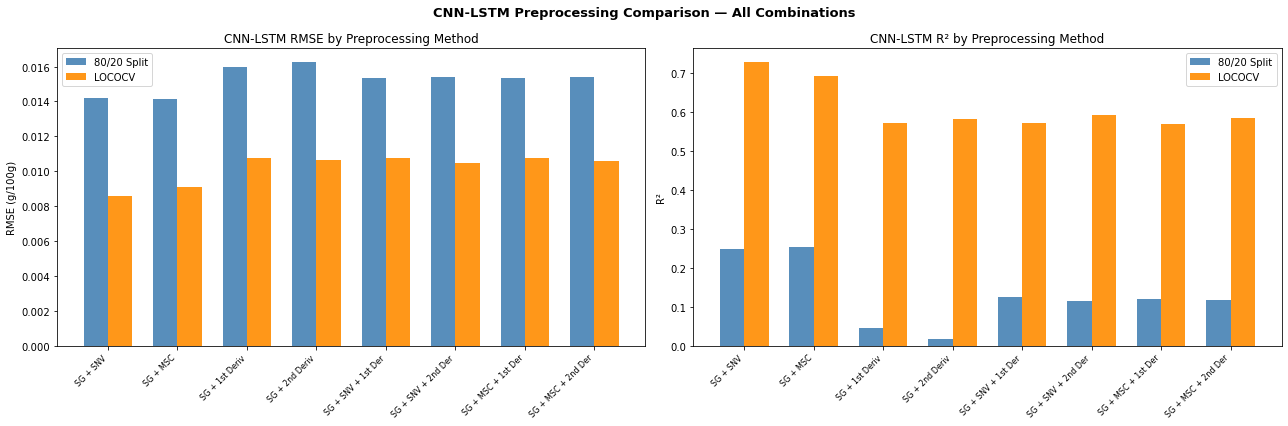

In [10]:
import pandas as pd

df_cnnlstm = pd.DataFrame(results_cnnlstm)

print("="*90)
print("         CNN-LSTM PREPROCESSING COMPARISON RESULTS")
print("="*90)
print(f"{'Preprocessing':<22} {'RMSE_8020':>10} {'R2_8020':>8} {'RPD_8020':>9} {'RMSE_LOCO':>10} {'R2_LOCO':>9} {'RPD_LOCO':>9}")
print("-"*90)
for _, row in df_cnnlstm.iterrows():
    print(f"{row['Preprocessing']:<22} "
          f"{row['RMSE_8020']:>10.4f} {row['R2_8020']:>8.4f} {row['RPD_8020']:>9.4f} "
          f"{row['RMSE_LOCO']:>10.4f} {row['R2_LOCO']:>9.4f} {row['RPD_LOCO']:>9.4f}")
print("="*90)

best_8020 = df_cnnlstm.loc[df_cnnlstm['RMSE_8020'].idxmin(), 'Preprocessing']
best_loco  = df_cnnlstm.loc[df_cnnlstm['RMSE_LOCO'].idxmin(), 'Preprocessing']
print(f"\nBest 80/20 preprocessing: {best_8020}")
print(f"Best LOCO  preprocessing: {best_loco}")

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
labels = df_cnnlstm['Preprocessing'].tolist()
x = np.arange(len(labels))
width = 0.35

ax1 = axes[0]
ax1.bar(x - width/2, df_cnnlstm['RMSE_8020'], width,
        color='steelblue', alpha=0.9, label='80/20 Split')
ax1.bar(x + width/2, df_cnnlstm['RMSE_LOCO'], width,
        color='darkorange', alpha=0.9, label='LOCOCV')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel("RMSE (g/100g)")
ax1.set_title("CNN-LSTM RMSE by Preprocessing Method")
ax1.legend()

ax2 = axes[1]
ax2.bar(x - width/2, df_cnnlstm['R2_8020'], width,
        color='steelblue', alpha=0.9, label='80/20 Split')
ax2.bar(x + width/2, df_cnnlstm['R2_LOCO'], width,
        color='darkorange', alpha=0.9, label='LOCOCV')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel("R²")
ax2.set_title("CNN-LSTM R² by Preprocessing Method")
ax2.legend()

plt.suptitle("CNN-LSTM Preprocessing Comparison — All Combinations",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("CNNLSTM_preprocessing_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

Best Configuration Scatter Plot:

In [ ]:
# Force use GPU 1 instead of GPU 0
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
device = torch.device('cuda')
print(f"Using GPU: {torch.cuda.get_device_name(0)}")
print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

In [ ]:
print("    CNN-LSTM FINAL RESULTS SUMMARY"):
# Best LOCO preprocessing = SG + SNV
X_best = snv(savitzky_golay_smooth(X))
X_tr, X_te, y_tr, y_te = train_test_split(
    X_best, y, test_size=0.2, random_state=42
)

torch.manual_seed(42)
model_final = CNNLSTMModel(input_size=1530, hidden_size=128, num_layers=2)
model_final, _, _ = train_model(
    model=model_final,
    X_train=X_tr, y_train=y_tr,
    X_val=X_te,   y_val=y_te,
    epochs=100, batch_size=32, lr=1e-4
)

model_final.eval()
with torch.no_grad():
    y_pred_te = model_final(
        torch.FloatTensor(X_te).to(device)
    ).cpu().numpy()

# LOCOCV
all_true_final, all_pred_final = [], []
for fold_idx, held_out in enumerate(cultivar_names):
    X_tr_l, y_tr_l = [], []
    X_te_l, y_te_l = [], []
    for folder_name, meta in CULTIVARS.items():
        spectra = all_data.get(folder_name, [])
        for rs, intens in spectra:
            arr     = np.array([intens])
            arr_pre = snv(savitzky_golay_smooth(arr))[0]
            if folder_name == held_out:
                X_te_l.append(arr_pre)
                y_te_l.append(meta['cys'])
            else:
                X_tr_l.append(arr_pre)
                y_tr_l.append(meta['cys'])

    torch.manual_seed(42)
    model_loco_f = CNNLSTMModel(input_size=1530, hidden_size=128, num_layers=2)
    model_loco_f, _, _ = train_model(
        model=model_loco_f,
        X_train=np.array(X_tr_l),
        y_train=np.array(y_tr_l),
        X_val=np.array(X_te_l),
        y_val=np.array(y_te_l),
        epochs=100, batch_size=32, lr=1e-4
    )
    model_loco_f.eval()
    with torch.no_grad():
        y_pred_l = model_loco_f(
            torch.FloatTensor(np.array(X_te_l)).to(device)
        ).cpu().numpy()
    all_true_final.extend(y_te_l)
    all_pred_final.extend(y_pred_l)

all_true_final = np.array(all_true_final)
all_pred_final = np.array(all_pred_final)

rmse_8020_f = np.sqrt(mean_squared_error(y_te, y_pred_te))
r2_8020_f   = r2_score(y_te, y_pred_te)
rpd_8020_f  = y_te.std() / rmse_8020_f
rmse_loco_f = np.sqrt(mean_squared_error(all_true_final, all_pred_final))
r2_loco_f   = r2_score(all_true_final, all_pred_final)
rpd_loco_f  = all_true_final.std() / rmse_loco_f

# ── Plot with different color per cultivar ──
colors = plt.cm.tab20(np.linspace(0, 1, 20))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 80/20 panel
ax1 = axes[0]
unique_cys = sorted(set(y_te))
for i, val in enumerate(unique_cys):
    mask  = y_te == val
    label = [meta['label'] for meta in CULTIVARS.values()
             if abs(meta['cys'] - val) < 0.0001]
    label = label[0] if label else str(round(val, 4))
    ax1.scatter(y_te[mask], y_pred_te[mask],
                alpha=0.4, s=10, color=colors[i], label=label)

min_val = min(y_te.min(), y_pred_te.min()) - 0.005
max_val = max(y_te.max(), y_pred_te.max()) + 0.005
ax1.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=1.5)
ax1.set_xlabel("True Cysteine (g/100g)")
ax1.set_ylabel("Predicted Cysteine (g/100g)")
ax1.set_title(f"80/20 Split\nRMSE={rmse_8020_f:.4f}  R²={r2_8020_f:.4f}  RPD={rpd_8020_f:.4f}")
ax1.legend(fontsize=6, ncol=2, loc='upper left')

# LOCO panel
ax2 = axes[1]
unique_cys_loco = sorted(set(all_true_final))
for i, val in enumerate(unique_cys_loco):
    mask  = all_true_final == val
    label = [meta['label'] for meta in CULTIVARS.values()
             if abs(meta['cys'] - val) < 0.0001]
    label = label[0] if label else str(round(val, 4))
    ax2.scatter(all_true_final[mask], all_pred_final[mask],
                alpha=0.4, s=10, color=colors[i], label=label)

min_val = min(all_true_final.min(), all_pred_final.min()) - 0.005
max_val = max(all_true_final.max(), all_pred_final.max()) + 0.005
ax2.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=1.5)
ax2.set_xlabel("True Cysteine (g/100g)")
ax2.set_ylabel("Predicted Cysteine (g/100g)")
ax2.set_title(f"LOCOCV\nRMSE={rmse_loco_f:.4f}  R²={r2_loco_f:.4f}  RPD={rpd_loco_f:.4f}")
ax2.legend(fontsize=6, ncol=2, loc='upper left')

plt.suptitle("CNN-LSTM Final Results — Best Configuration (SG + SNV)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("CNNLSTM_final_results.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*55)
print("    CNN-LSTM FINAL RESULTS SUMMARY")
print("="*55)
print(f"{'Metric':<20} {'80/20 Split':>15} {'LOCOCV':>15}")
print("-"*55)
print(f"{'RMSE':<20} {rmse_8020_f:>15.4f} {rmse_loco_f:>15.4f}")
print(f"{'R²':<20} {r2_8020_f:>15.4f} {r2_loco_f:>15.4f}")
print(f"{'RPD':<20} {rpd_8020_f:>15.4f} {rpd_loco_f:>15.4f}")
print(f"{'Preprocessing':<20} {'SG + SNV':>15} {'SG + SNV':>15}")
print("="*55)